In [1]:
!pip install opendatasets

# Downloading the dataset from Kaggle

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: hafijurraman
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:01<00:00, 1.62GB/s]


# Importing necessary libraries

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

# Counting image per class in TRAIN dataset & plotting

In [4]:
train_dir = "/content/chest-xray-pneumonia/chest_xray/train"

In [5]:
classes = os.listdir(train_dir)
classes = [c for c in classes if os.path.isdir(os.path.join(train_dir, c))]

class_counts = {}

for c in classes:
    class_path = os.path.join(train_dir, c)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[c] = len(images)

print("Class distribution in TRAIN set:")
for k, v in class_counts.items():
    print(f"{k}: {v} images")

Class distribution in TRAIN set:
NORMAL: 1341 images
PNEUMONIA: 3875 images


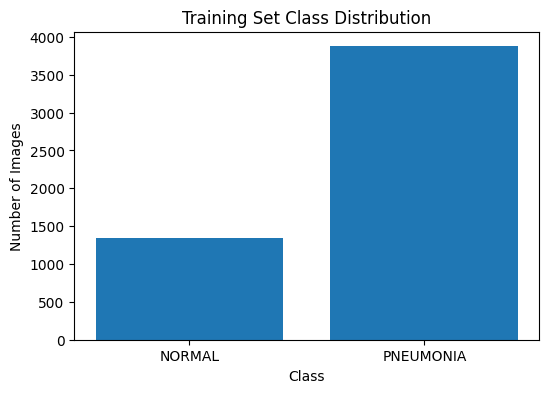

In [6]:
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()

# Counting image per class in TEST dataset & plotting

In [7]:
test_dir = "/content/chest-xray-pneumonia/chest_xray/test"

In [8]:
classes = os.listdir(train_dir)
classes = [c for c in classes if os.path.isdir(os.path.join(test_dir, c))]

class_counts = {}

for c in classes:
    class_path = os.path.join(test_dir, c)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[c] = len(images)

print("Class distribution in TEST set:")
for k, v in class_counts.items():
    print(f"{k}: {v} images")

Class distribution in TEST set:
NORMAL: 234 images
PNEUMONIA: 390 images


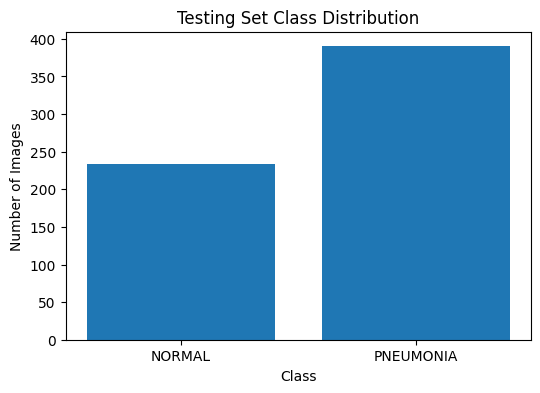

In [9]:
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Testing Set Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()

# Counting image per class in VAL dataset & plotting

In [10]:
val_dir = "/content/chest-xray-pneumonia/chest_xray/val"

In [11]:
classes = os.listdir(train_dir)
classes = [c for c in classes if os.path.isdir(os.path.join(val_dir, c))]

class_counts = {}

for c in classes:
    class_path = os.path.join(val_dir, c)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[c] = len(images)

print("Class distribution in VAL set:")
for k, v in class_counts.items():
    print(f"{k}: {v} images")

Class distribution in VAL set:
NORMAL: 8 images
PNEUMONIA: 8 images


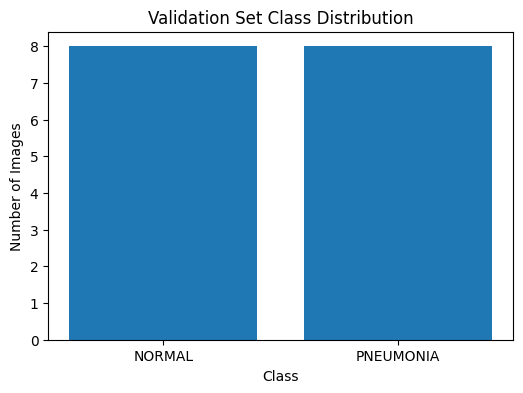

In [12]:
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Validation Set Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()

# Checking Image size

In [13]:
sizes = []

for c in classes:
    class_path = os.path.join(train_dir, c)
    images = os.listdir(class_path)[:50]  # sample first 50
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print("Example image sizes (width, height):")
print(Counter(sizes))

Example image sizes (width, height):
Counter({(1152, 672): 2, (1906, 1527): 1, (1596, 1233): 1, (2844, 2067): 1, (2566, 2321): 1, (1450, 1275): 1, (1650, 1078): 1, (1504, 1283): 1, (1422, 1186): 1, (1334, 1171): 1, (1360, 1128): 1, (1522, 1221): 1, (1630, 1179): 1, (1562, 1133): 1, (1728, 1333): 1, (2414, 1731): 1, (2101, 1606): 1, (1720, 1507): 1, (1688, 1542): 1, (2156, 1936): 1, (1906, 1627): 1, (1920, 1920): 1, (1902, 1499): 1, (1530, 1028): 1, (1546, 1255): 1, (1402, 1105): 1, (1288, 1080): 1, (2694, 2625): 1, (1376, 1051): 1, (1522, 1093): 1, (1632, 1260): 1, (1906, 1909): 1, (1748, 1299): 1, (1654, 1541): 1, (1300, 1051): 1, (1438, 1059): 1, (1408, 1090): 1, (2040, 2059): 1, (2358, 1959): 1, (1778, 1318): 1, (1620, 1356): 1, (1372, 1074): 1, (1422, 1125): 1, (1704, 1449): 1, (1654, 1259): 1, (1640, 1469): 1, (2138, 1928): 1, (1620, 1175): 1, (1118, 932): 1, (1438, 1140): 1, (2619, 2628): 1, (1232, 744): 1, (1216, 672): 1, (936, 568): 1, (1160, 560): 1, (1256, 792): 1, (1152, 744

#visualizing Images

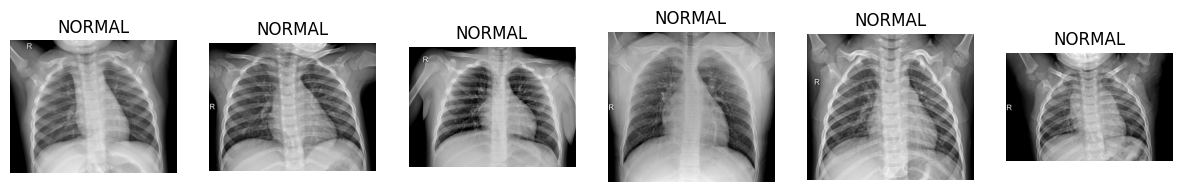

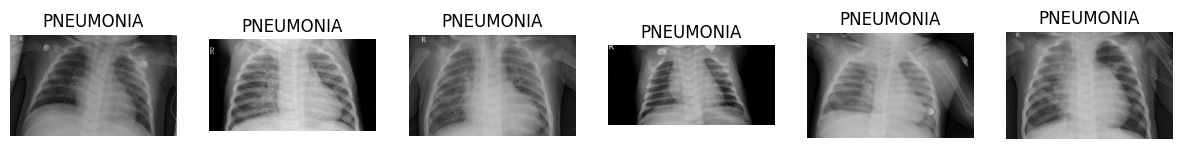

In [14]:
def show_samples(class_name, num_samples=6):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)[:num_samples]

    plt.figure(figsize=(15,5))
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis("off")
    plt.show()

for c in classes:
    show_samples(c, num_samples=6)

# Creating a Stratified Validation Split since we have only 16 images in Val dataset, 8 Pneumonia and 8 Normal, which is too less.

In [15]:
import os, shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

root = Path("/content/chest-xray-pneumonia/chest_xray")
train_dir = root / "train"
split_root = root / "splits"

# Collect image paths and labels
paths, labels = [], []
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])

for c in classes:
    for img in (train_dir / c).glob("*"):
        if img.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            paths.append(img)
            labels.append(c)

# Stratified split (80/20)
train_p, val_p = train_test_split(
    paths, test_size=0.2, stratify=labels, random_state=42
)

# Create output folders
for split_name, split_paths in [("train", train_p), ("val", val_p)]:
    for c in classes:
        (split_root / split_name / c).mkdir(parents=True, exist_ok=True)

    for p in split_paths:
        shutil.copy2(p, split_root / split_name / p.parent.name / p.name)

print("Split completed.")

Split completed.


# Now checking the validation counts

In [16]:
def count_images(folder):
    counts = {}
    for c in classes:
        counts[c] = len(list((folder / c).glob("*")))
    return counts

print("Train split:", count_images(split_root / "train"))
print("Val split  :", count_images(split_root / "val"))

Train split: {'NORMAL': 1073, 'PNEUMONIA': 3099}
Val split  : {'NORMAL': 268, 'PNEUMONIA': 776}


# # Checking GPU memory usage

In [17]:
!nvidia-smi

Sun Mar  1 09:32:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# ✅ ResNet-18 Architecture Implementation (Binary Classification Version)

In [18]:
"""
Building an 18-layer residual network (ResNet-18) from scratch.
Adapted for binary classification (PNEUMONIA vs NORMAL).
Based on "Deep Residual Learning for Image Recognition"
https://arxiv.org/abs/1512.03385
"""

import torch
import torch.nn as nn
import torchvision


# ------------------------------
# Basic Residual Block
# ------------------------------
class BasicBlock(nn.Module):
    """The Residual Block for ResNet-18"""

    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, downsample: bool = False):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if downsample:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity
        out = self.relu(out)

        return out


# ------------------------------
# ResNet-18 Model
# ------------------------------
class ResNet18(nn.Module):
    """ResNet-18 architecture"""

    def __init__(self, n_classes: int = 2):
        super().__init__()

        # Initial convolution layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = nn.Sequential(
            BasicBlock(64, 64),
            BasicBlock(64, 64),
        )

        self.layer2 = nn.Sequential(
            BasicBlock(64, 128, stride=2, downsample=True),
            BasicBlock(128, 128),
        )

        self.layer3 = nn.Sequential(
            BasicBlock(128, 256, stride=2, downsample=True),
            BasicBlock(256, 256),
        )

        self.layer4 = nn.Sequential(
            BasicBlock(256, 512, stride=2, downsample=True),
            BasicBlock(512, 512),
        )

        # Global Average Pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final Fully Connected Layer
        self.fc = nn.Linear(512, n_classes)

        self._initialize_weights()

    # ------------------------------
    # Forward Pass
    # ------------------------------
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)          # [batch_size, 512, 1, 1]
        x = torch.flatten(x, 1)      # [batch_size, 512]
        out = self.fc(x)             # [batch_size, n_classes]

        return out

    # ------------------------------
    # Weight Initialization
    # ------------------------------
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    # ------------------------------
    # Load ImageNet Pretrained Weights
    # ------------------------------
    @classmethod
    def from_pretrained(cls):
        """
        Load ImageNet pretrained weights into this implementation.
        Final FC layer is replaced for binary classification.
        """

        print("Loading pretrained ResNet-18 weights from torchvision...")

        model = cls(n_classes=2)
        state_dict = model.state_dict()

        pretrained = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
        )
        pretrained_dict = pretrained.state_dict()

        for name, param in pretrained_dict.items():
            if name.startswith("fc"):
                continue
            state_dict[name].copy_(param)

        model.load_state_dict(state_dict)

        return model

# Task 1.1 — Training From Scratch

In [19]:
model = ResNet18(n_classes=2).cuda()

# Task 1.2 — Pretrained Fine-Tuning

In [20]:
model = ResNet18.from_pretrained().cuda()

Loading pretrained ResNet-18 weights from torchvision...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]


# Full Training pipeline

In [26]:
device = torch.device("cuda")

# ---------------------------------------
# DATA TRANSFORMS
# ---------------------------------------
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

data_root = "/content/chest-xray-pneumonia/chest_xray/splits"

train_dataset = datasets.ImageFolder(os.path.join(data_root, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_root, "val"), transform=val_transform)

test_dataset  = datasets.ImageFolder("/content/chest-xray-pneumonia/chest_xray/test",
                                     transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# ---------------------------------------
# CLASS WEIGHTS (for imbalance)
# ---------------------------------------
targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets)
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

class_weights = torch.tensor(class_weights, dtype=torch.float32).cuda()
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

# ---------------------------------------
# MODEL (CHOOSE ONE)
# ---------------------------------------
# Task 1.1
#model = ResNet18(n_classes=2).cuda()

# Task 1.2
model = ResNet18.from_pretrained().cuda()

# ---------------------------------------
# OPTIMIZER + SCHEDULER
# ---------------------------------------
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

scaler = GradScaler()   # for mixed precision

# ---------------------------------------
# TRAINING LOOP
# ---------------------------------------
epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss_total += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss_total / len(val_loader)
    val_acc = correct / total

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("Training Complete!")

Class counts: [1073 3099]
Class weights: tensor([1.4856, 0.5144], device='cuda:0')
Loading pretrained ResNet-18 weights from torchvision...


/tmp/ipython-input-11156/2302756929.py:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()   # for mixed precision
/tmp/ipython-input-11156/2302756929.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-11156/2302756929.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/20] Train Loss: 0.1140, Train Acc: 0.9521 | Val Loss: 0.2942, Val Acc: 0.8851
Epoch [2/20] Train Loss: 0.0656, Train Acc: 0.9739 | Val Loss: 0.0998, Val Acc: 0.9626
Epoch [3/20] Train Loss: 0.0511, Train Acc: 0.9820 | Val Loss: 0.0481, Val Acc: 0.9837
Epoch [4/20] Train Loss: 0.0432, Train Acc: 0.9832 | Val Loss: 0.0485, Val Acc: 0.9799
Epoch [5/20] Train Loss: 0.0444, Train Acc: 0.9832 | Val Loss: 0.0435, Val Acc: 0.9828
Epoch [6/20] Train Loss: 0.0524, Train Acc: 0.9880 | Val Loss: 0.0579, Val Acc: 0.9761
Epoch [7/20] Train Loss: 0.0391, Train Acc: 0.9854 | Val Loss: 0.0299, Val Acc: 0.9904
Epoch [8/20] Train Loss: 0.0262, Train Acc: 0.9904 | Val Loss: 0.0495, Val Acc: 0.9828
Epoch [9/20] Train Loss: 0.0197, Train Acc: 0.9921 | Val Loss: 0.0391, Val Acc: 0.9837
Epoch [10/20] Train Loss: 0.0118, Train Acc: 0.9964 | Val Loss: 0.0296, Val Acc: 0.9895
Epoch [11/20] Train Loss: 0.0093, Train Acc: 0.9978 | Val Loss: 0.0350, Val Acc: 0.9866
Epoch [12/20] Train Loss: 0.0071, Train A

# TEST EVALUATION (WITH CLASS-WISE ACCURACY)

In [27]:
model.eval()
correct = 0
total = 0

class_correct = [0, 0]
class_total = [0, 0]

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

print("Test Accuracy:", correct / total)
print("NORMAL Accuracy:", class_correct[0] / class_total[0])
print("PNEUMONIA Accuracy:", class_correct[1] / class_total[1])

Test Accuracy: 0.842948717948718
NORMAL Accuracy: 0.5854700854700855
PNEUMONIA Accuracy: 0.9974358974358974


# LOSS CURVES

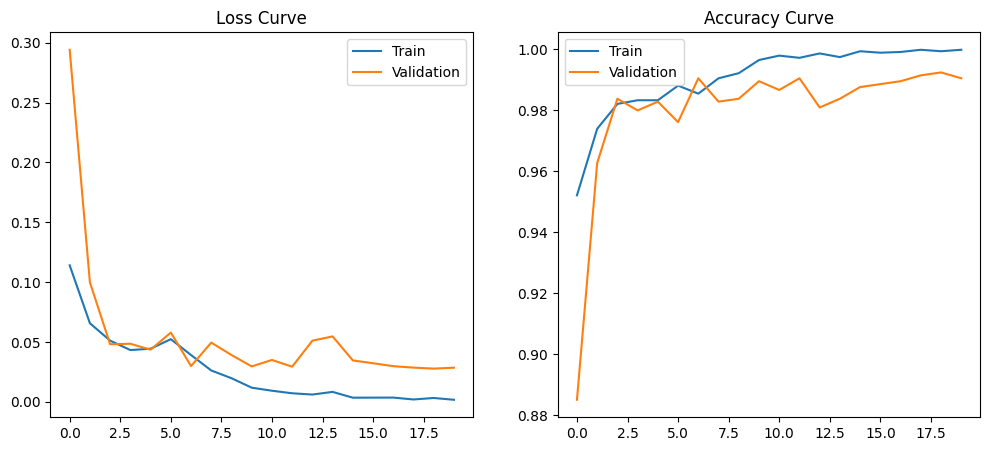

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy Curve")
plt.legend()

plt.show()